2025-06-11 09:15:47.093866: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-11 09:15:47.125184: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-11 09:15:47.125207: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-11 09:15:47.126192: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-11 09:15:47.131962: I tensorflow/core/platform/cpu_feature_guar

[]


2025-06-11 09:15:48.312024: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_COMPAT_NOT_SUPPORTED_ON_DEVICE: forward compatibility was attempted on non supported HW
2025-06-11 09:15:48.312045: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:129] retrieving CUDA diagnostic information for host: balanis
2025-06-11 09:15:48.312049: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:136] hostname: balanis
2025-06-11 09:15:48.312117: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:159] libcuda reported version is: 550.144.3
2025-06-11 09:15:48.312148: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] kernel reported version is: 550.120.0
2025-06-11 09:15:48.312151: E external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:244] kernel version 550.120.0 does not match DSO version 550.144.3 -- cannot find working devices in this configuration


data ['LA_RSPV_CAF_150115', 'Simulation_01_200428_001_001', 'Simulation_01_200316_001_  5', 'Simulation_01_191001_001_002', 'Simulation_01_200428_001_005', 'Simulation_01_190717_001_001', 'Simulation_01_200212_001_  7', 'Simulation_01_191001_001_007', 'LA_RSPV_150113', 'Simulation_01_210119_001_001', 'Simulation_01_210205_001_003', 'LA_PLAW_140612', 'Simulation_01_190717_001_004', 'Simulation_01_201223_001_002', 'Simulation_01_200212_001_  1', 'LA_LSPV_150203', 'Simulation_01_190619_001_003', 'Simulation_01_200428_001_003', 'Simulation_01_190619_001_004', 'Simulation_01_190717_001_003', 'Simulation_01_190502_001_006', 'LA_LSPV_150113', 'Simulation_01_190502_001_004', 'RA_RAFW_140807', 'Simulation_01_190717_001_002', 'Simulation_01_200316_001_  3', 'Simulation_01_200316_001_  4', 'RA_RAA_141230', 'Sinusal_150629', 'RA_RAA_141216', 'Simulation_01_200428_001_002', 'Simulation_01_210210_001_001', 'Simulation_01_210208_001_002', 'Simulation_01_190619_001_001', 'Simulation_01_200212_001_  9'

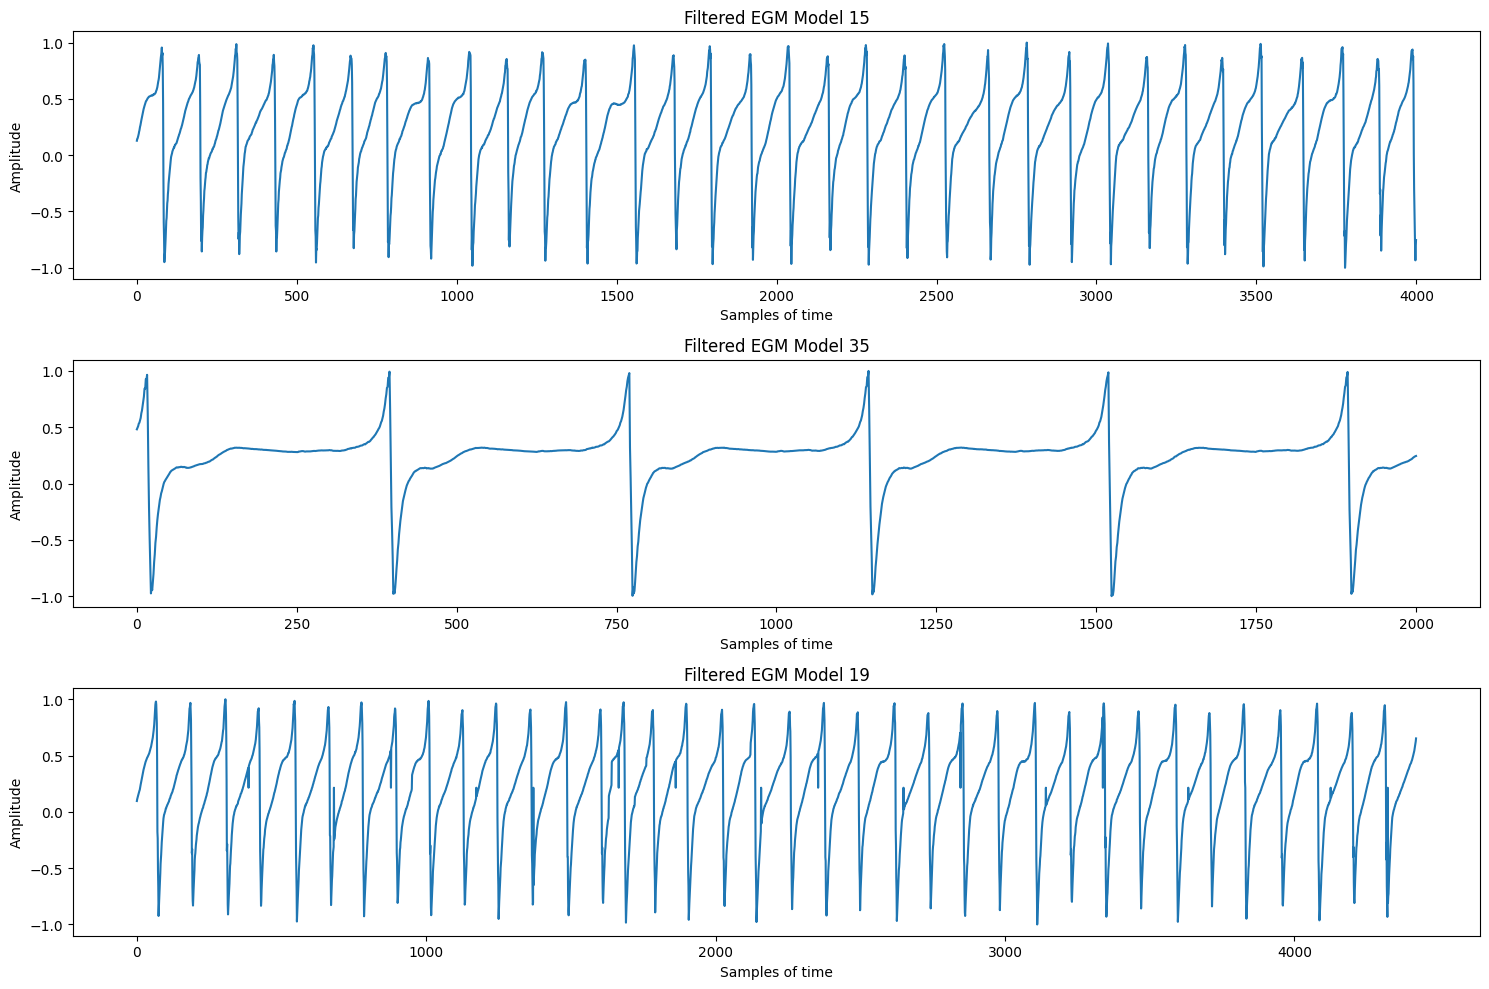

10
Transfer matrices LOADED - var: **transfer_matrices** 
BSPS Models LOADED - var: **bsps_all_models** 
BSPS 64 Models LOADED - var: **bsps_64_all_models** 
550
(3610, 2499)
(3610, 2499)
(64, 2499)
(3970, 2499)
(64, 2499)
(64, 2001)
550
BSPS 64 Models LOADED - var: **bsps_64_all_models** 


In [1]:
import os
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/home/alumnos/mburgosc/cuda-fake"

import tensorflow as tf

import tensorflow as tf 
import numpy as np
gpus = tf.config.list_physical_devices("GPU")

print(gpus)

import import_data

egms_all_models = import_data.egms_all_models
egms_values = import_data.egms_values
egms_filtered_norm = import_data.egms_filtered_norm
bsps_all_models = import_data.bsps_all_models
bsps_64_all_models = import_data.bsps_64_all_models
transfer_matrices = import_data.transfer_matrices
models_names = import_data.models_names
bsps_64_all_models_names = import_data.bsps_64_all_models_names

In [2]:
print(bsps_64_all_models_names[:100])
print(len(bsps_64_all_models_names))
# models_name_full = []
# for name in models_names:
#     models_name_full.extend([name] * 10)

models_name_full = bsps_64_all_models_names
# Verifica que coinciden
print(len(models_name_full))  # Debería dar 240
filtered_models = []
filtered_models_names = []

for model, name_model in zip(bsps_64_all_models, models_name_full):
    new_model = []
    new_model2 = []

    for node in model:
        original_length = len(node)

        if original_length < 2000:
            continue

        if 2000 <= original_length <= 2501:
            node = node[:2000]
            new_model.append(node)
        elif 4000 <= original_length <= 4501:
            node = node[:4000]
            new_model.append(node[0:2000])
            new_model2.append(node[2000:4000])
        else:
            continue


    if len(new_model) > 0:
        filtered_models.append(new_model)
        filtered_models_names.append(name_model)  # Añadimos el nombre del modelo
    if len(new_model2) > 0:
        filtered_models.append(new_model2)
        filtered_models_names.append(name_model)
        
bsps_64_filtered_models = filtered_models

print(len(bsps_64_filtered_models))
print(len(filtered_models_names))
print(filtered_models_names)
print(bsps_64_filtered_models[0])

print(filtered_models_names[140])

['LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_200428_001_005', 'Simulation_01_200428_001_005', 'Simulation_01_200428_001_005', 'Simulation_01_200428_001_005', 'Simulation

In [3]:
from collections import OrderedDict
unique_models = list(OrderedDict.fromkeys(filtered_models_names))
print(len(unique_models))
print(unique_models)

model_to_indices = {m: [] for m in unique_models}  # DICCIONARIO CON NOMBRES DE MODELOS Y SUS INDICES EN filtered_models_names
for i, name in enumerate(filtered_models_names):
    if name in unique_models:
        model_to_indices[name].append(i)
print(f"Índices de modelos: {model_to_indices}")

54
['LA_RSPV_CAF_150115', 'Simulation_01_200316_001_  5', 'Simulation_01_191001_001_002', 'Simulation_01_200428_001_005', 'Simulation_01_190717_001_001', 'Simulation_01_200212_001_  7', 'Simulation_01_191001_001_007', 'LA_RSPV_150113', 'Simulation_01_190717_001_004', 'Simulation_01_200212_001_  1', 'LA_LSPV_150203', 'Simulation_01_190619_001_003', 'Simulation_01_200428_001_003', 'Simulation_01_190619_001_004', 'Simulation_01_190717_001_003', 'Simulation_01_190502_001_006', 'LA_LSPV_150113', 'Simulation_01_190502_001_004', 'RA_RAFW_140807', 'Simulation_01_190717_001_002', 'Simulation_01_200316_001_  3', 'Simulation_01_200316_001_  4', 'RA_RAA_141230', 'Sinusal_150629', 'RA_RAA_141216', 'Simulation_01_190619_001_001', 'Simulation_01_200212_001_  9', 'Simulation_01_200316_001_  1', 'Simulation_01_200316_001_  8', 'Simulation_01_200428_001_004', 'Simulation_01_200212_001_  8', 'Simulation_01_200212_001_ 10', 'Simulation_01_191001_001_001', 'Simulation_01_200428_001_007', 'Simulation_01_200

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split


# Leer el CSV
csv_df = pd.read_csv('annotations.csv', header=None)

# Separar por ';'
csv_split = csv_df[0].str.split(';', expand=True)
csv_names = csv_split[0].str.strip().tolist()  # Eliminar espacios
csv_labels = csv_split[1].astype(int).tolist()

# Lista de modelos únicos que quieres filtrar (asegúrate de que está definida)
# unique_models = [...]

# Crear un diccionario con todos los nombres y etiquetas
name_to_label = dict(zip(csv_names, csv_labels))

# Filtrar sólo los que están en unique_models
filtered_unique_models = [m for m in unique_models if name_to_label.get(m) != 1]
print(len(filtered_unique_models))

filtered_labels = [name_to_label[m] for m in filtered_unique_models]

train_models, test_models, train_labels, test_labels = train_test_split(
    filtered_unique_models,
    filtered_labels,
    test_size=0.3,
    stratify=filtered_labels,
    random_state=42
)

# Mostrar resultados
print(filtered_labels)
print(len(filtered_labels))

print("Total modelos únicos con etiqueta:", len(filtered_unique_models))


print("Modelos de entrenamiento:", len(train_models))
print("Modelos de prueba:", len(test_models))
print("Etiquetas de entrenamiento:", len(train_labels))
print("Etiquetas de prueba:", len(test_labels))

# Opcional: Ver distribución
from collections import Counter
print("Distribución train:", Counter(train_labels))
print("Distribución test:", Counter(test_labels))

52
[3, 4, 2, 4, 2, 4, 2, 3, 2, 4, 3, 2, 4, 2, 2, 2, 3, 2, 3, 2, 4, 2, 3, 4, 2, 4, 4, 2, 2, 2, 2, 2, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 3, 2, 2, 2, 3, 4]
52
Total modelos únicos con etiqueta: 52
Modelos de entrenamiento: 36
Modelos de prueba: 16
Etiquetas de entrenamiento: 36
Etiquetas de prueba: 16
Distribución train: Counter({2: 21, 4: 9, 3: 6})
Distribución test: Counter({2: 10, 4: 4, 3: 2})


In [5]:
X_train = []
y_train = []

for model_name, label in zip(train_models, train_labels):
    indices = model_to_indices.get(model_name, [])
    for idx in indices:
        X_train.append(filtered_models[idx])
        y_train.append(label)

X_test = []
y_test = []

for model_name, label in zip(test_models, test_labels):
    indices = model_to_indices.get(model_name, [])
    for idx in indices:
        X_test.append(filtered_models[idx])
        y_test.append(label)

# Verificación rápida
print(f"Total X_train: {len(X_train)}, y_train: {len(y_train)}")
print(f"Total X_test: {len(X_test)}, y_test: {len(y_test)}")

print(Counter(y_train))
print(Counter(y_test))

X_train = np.array(X_train)
X_test = np.array(X_test)


Total X_train: 560, y_train: 560
Total X_test: 250, y_test: 250
Counter({2: 410, 4: 90, 3: 60})
Counter({2: 190, 4: 40, 3: 20})


(64, 2000)


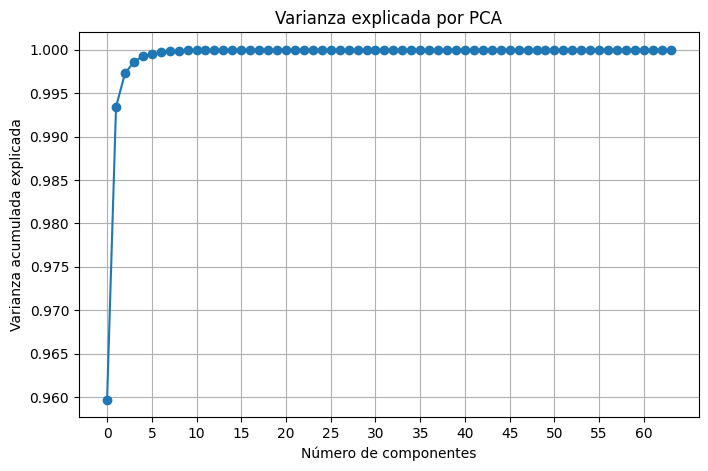

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

model = X_train[100]  # Un modelo: shape (64 nodos, 1000 muestras)
print(model.shape)
pca = PCA()
pca.fit(model)

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(explained_variance), marker='o')

# Personalizar el eje x para mostrar más marcas
plt.xticks(np.arange(0, len(explained_variance), step=5))  # Ajustar el paso según lo necesites

plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada explicada')
plt.title('Varianza explicada por PCA')
plt.grid(True)
plt.show()


In [ ]:
from sklearn.decomposition import PCA

# APLICAR PCA A CADA MODELO
n_components = 3
X_train_pca = []
X_test_pca = []

for dataset in [X_train, X_test]:
    X_pca_set = []

    for model in dataset:  
        
        # Transponer a (1000, 64) para que las features sean los nodos
        model_T = model.T
        pca = PCA(n_components=n_components)
        model_pca = pca.fit_transform(model_T)  # (1000, 3)

        # Si quieres devolverlo como (64, 3) puedes transponer de nuevo
        model_pca = model_pca.T  # (3, 1000)
        X_pca_set.append(model_pca)

    if dataset is X_train:
        X_train_pca = X_pca_set
    else:
        X_test_pca = X_pca_set

print(f"✅ PCA aplicado por modelo. Ejemplo dimensiones: {X_train_pca[0].shape} ")

✅ PCA aplicado por modelo. Ejemplo dimensiones: (3, 2000) (3 componentes x 500 muestras)


In [8]:
from kymatio import Scattering1D
 
# APLICAR SCATTERING A CADA MODELO
J = 4
Q = (16,1)
ws_coeff_all_mods = []  
ws_coeff_all_train_mods = []  
ws_coeff_all_test_mods = []  

models_shortened = [X_train_pca, X_test_pca]


for i in range(len(models_shortened)):
    for model in models_shortened[i]:
        
        print("Samples of every node:", len(model[0]), "samples")

        model_coeffs = []  
        
        for j in range(len(model)):
            signal = np.array(model[j])  
            len_signal = len(signal)
            
            scattering = Scattering1D(J=J, shape=(len_signal,), Q=Q)
            Sx = scattering(signal)  
            
            model_coeffs.append(Sx)  
        
        if i == 0:
            ws_coeff_all_train_mods.append(np.stack(model_coeffs))
        elif i == 1:
            ws_coeff_all_test_mods.append(np.stack(model_coeffs))
        ws_coeff_all_mods.append(np.stack(model_coeffs))  
        print(f"Shape del tensor: {ws_coeff_all_mods[-1].shape}")


Samples of every node: 2000 samples
Shape del tensor: (3, 74, 125)
Samples of every node: 2000 samples
Shape del tensor: (3, 74, 125)
Samples of every node: 2000 samples
Shape del tensor: (3, 74, 125)
Samples of every node: 2000 samples
Shape del tensor: (3, 74, 125)
Samples of every node: 2000 samples
Shape del tensor: (3, 74, 125)
Samples of every node: 2000 samples
Shape del tensor: (3, 74, 125)
Samples of every node: 2000 samples
Shape del tensor: (3, 74, 125)
Samples of every node: 2000 samples
Shape del tensor: (3, 74, 125)
Samples of every node: 2000 samples
Shape del tensor: (3, 74, 125)
Samples of every node: 2000 samples
Shape del tensor: (3, 74, 125)
Samples of every node: 2000 samples
Shape del tensor: (3, 74, 125)
Samples of every node: 2000 samples
Shape del tensor: (3, 74, 125)
Samples of every node: 2000 samples
Shape del tensor: (3, 74, 125)
Samples of every node: 2000 samples
Shape del tensor: (3, 74, 125)
Samples of every node: 2000 samples
Shape del tensor: (3, 74, 

In [9]:
ws_coeff_all_test_mods = np.array(ws_coeff_all_test_mods)
ws_coeff_all_train_mods = np.array(ws_coeff_all_train_mods)

X_train_final = ws_coeff_all_train_mods.reshape(ws_coeff_all_train_mods.shape[0], -1)
X_test_final = ws_coeff_all_test_mods.reshape(ws_coeff_all_test_mods.shape[0], -1)
print(X_train_final.shape, X_test_final.shape)

print(y_test)

(560, 27750) (250, 27750)
[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [10]:
print(Counter(y_train))
print(Counter(y_test))

Counter({2: 410, 4: 90, 3: 60})
Counter({2: 190, 4: 40, 3: 20})


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, log_loss
from sklearn.preprocessing import label_binarize
import numpy as np

# Supongamos que ya tienes:
# X_train, y_train, X_test, y_test (multiclase)
# y_train, y_test con clases como 0,1,2,...,n_classes-1

# Entrenar Random Forest
rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, max_depth=None, random_state=42)
rf.fit(X_train_final, y_train)

# Predecir clases
y_pred = rf.predict(X_test_final)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Obtener probabilidades predichas (necesarias para AUC multiclase y log loss)
y_proba = rf.predict_proba(X_test_final)  # shape (n_samples, n_classes)

# AUC ROC multiclase requiere que las etiquetas estén binarizadas (one-hot)
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

# Calcular AUC-ROC multiclase (One-vs-Rest)
auc_roc = roc_auc_score(y_test_bin, y_proba, multi_class='ovr')
print("AUC-ROC (multiclase OVR):", auc_roc)

# Calcular Log Loss
loss = log_loss(y_test_bin, y_proba)
print("Log loss:", loss)


Classification Report:
               precision    recall  f1-score   support

           2       1.00      0.95      0.97       190
           3       0.67      1.00      0.80        20
           4       1.00      1.00      1.00        40

    accuracy                           0.96       250
   macro avg       0.89      0.98      0.92       250
weighted avg       0.97      0.96      0.96       250

Confusion Matrix:
 [[180  10   0]
 [  0  20   0]
 [  0   0  40]]
AUC-ROC (multiclase OVR): 0.9852981184846173
Log loss: 0.11982188047065899


In [12]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
# Distribución de búsqueda
param_dist = {
    'max_depth': [None] + list(range(10, 50, 10)),
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 5),
    'bootstrap': [True, False], 
    'max_features': ['sqrt', 'log2', None],
}

random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist,
                                   n_iter=50, cv=5, random_state=42,
                                   n_jobs=-1, verbose=2, scoring='accuracy')

random_search.fit(X_train_final, y_train)

# Mejor modelo
best_model = random_search.best_estimator_
print("Mejores hiperparámetros:", random_search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END bootstrap=False, max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=3; total time=   0.5s
[CV] END bootstrap=False, max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=3; total time=   0.5s
[CV] END bootstrap=True, max_depth=30, max_features=log2, min_samples_leaf=1, min_samples_split=8; total time=   0.4s
[CV] END bootstrap=True, max_depth=30, max_features=log2, min_samples_leaf=1, min_samples_split=8; total time=   0.4s
[CV] END bootstrap=False, max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=3; total time=   0.6s
[CV] END bootstrap=True, max_depth=30, max_features=log2, min_samples_leaf=1, min_samples_split=8; total time=   0.5s
[CV] END bootstrap=False, max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=3; total time=   0.7s
[CV] END bootstrap=False, max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=3; total ti

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, log_loss, accuracy_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Entrenar Random Forest
rf = RandomForestClassifier(class_weight='balanced', n_estimators=1000, max_depth=40, random_state=42, 
                            max_features=None, min_samples_split=4, min_samples_leaf=2, bootstrap=True)

rf.fit(X_train_final, y_train)

# Predecir clases
y_pred = rf.predict(X_test_final)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", cm)
print("Sensitivity (Recall):", sensitivity)
print("Specificity:", specificity)

y_proba = rf.predict_proba(X_test_final)[:, 1]
print("AUC-ROC:", roc_auc_score(y_test, y_proba))
print("Log loss:", log_loss(y_test, y_proba))


ValueError: too many values to unpack (expected 4)

Class 2: 31 model
Class 3: 8 model
Class 1: 2 model
Class 4: 13 model


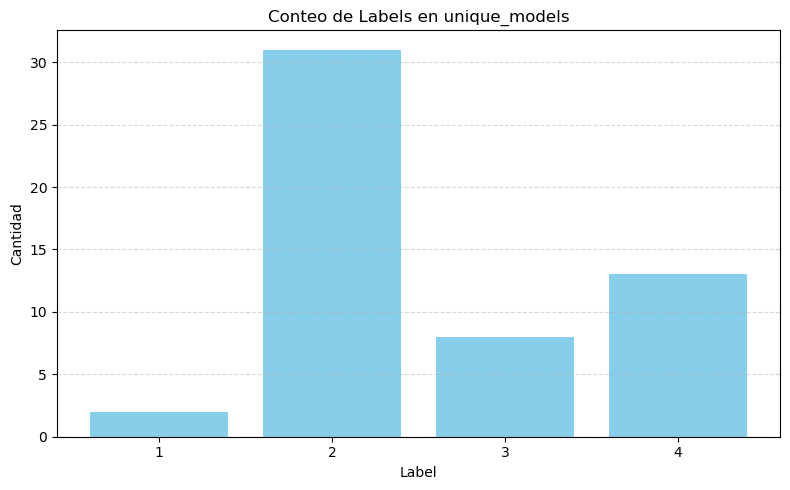

In [58]:
from collections import Counter
import matplotlib.pyplot as plt

label_counts = Counter(filtered_labels)

# Mostrar el conteo de cada etiqueta
for label, count in label_counts.items():
    print(f"Class {label}: {count} model")


# Contar los labels
label_counts = Counter(filtered_labels)

# Preparar datos
labels = sorted(label_counts.keys())
counts = [label_counts[label] for label in labels]

# Graficar
plt.figure(figsize=(8, 5))
plt.bar(labels, counts, color='skyblue')
plt.xlabel('Label')
plt.ylabel('Cantidad')
plt.title('Conteo de Labels en unique_models')
plt.xticks(labels)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()




In [38]:
import pandas as pd
import random
from collections import defaultdict

# Cargar CSV y construir nombre → label
df = pd.read_csv('annotations.csv', header=None)
csv_split = df[0].str.split(';', expand=True)
csv_names = csv_split[0].str.strip().tolist()
csv_labels = csv_split[1].astype(int).tolist()
name_to_label = dict(zip(csv_names, csv_labels))

# Lista de modelos a filtrar (asegúrate de tener esta lista)
# unique_models = [...]

# Eliminar solo la clase 5
filtered_labels = {
    name: name_to_label[name]
    for name in unique_models
    if name in name_to_label and name_to_label[name] != 1
}

# Agrupar por clase
class_to_models = defaultdict(list)
for name, label in filtered_labels.items():
    class_to_models[label].append(name)

# Balancear: buscar la clase con menos modelos
min_count = min(len(models) for models in class_to_models.values())
print(min_count)
# Seleccionar aleatoriamente `min_count` modelos de cada clase
balanced_models = []
for label, models in class_to_models.items():
    selected = random.sample(models, min_count)
    balanced_models.extend(selected)

print(f"Total de modelos seleccionados: {len(balanced_models)}")
print("Clases en el conjunto balanceado:", list(class_to_models.keys()))
print(balanced_models[:10])  # Mostrar algunos ejemplos


print(len(balanced_models))
print(len(filtered_labels))

8
Total de modelos seleccionados: 24
Clases en el conjunto balanceado: [2, 3, 4]
['Simulation_01_190619_001_003', 'Simulation_01_190717_001_002', 'Simulation_01_200316_001_  6', 'Simulation_01_190502_001_005', 'TwoRotors_181219', 'Simulation_01_200428_001_008', 'Simulation_01_190619_001_004', 'Simulation_01_190502_001_004', 'RA_RAA_141230', 'LA_RSPV_CAF_150115']
24
52


In [39]:
# Lista final de labels, en el orden que aparecen en bsps_64_filtered_models para los modelos en balanced_models
final_labels = []

for model_name in balanced_models:
    if model_name in model_to_indices and model_name in name_to_label:
        label = name_to_label[model_name]
        num_versions = len(model_to_indices[model_name])  # cuántos datos tiene ese modelo
        final_labels.extend([label] * num_versions)

print("Total de labels generados:", len(final_labels))
print("Primeros labels:", final_labels)

Counter(final_labels)

import numpy as np
final_indices = []

for model_name in balanced_models:
    if model_name in model_to_indices:
        final_indices.extend(model_to_indices[model_name])

final_data = [bsps_64_filtered_models[i] for i in final_indices]
print(len(final_data[20][0]))

Total de labels generados: 310
Primeros labels: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
2000


In [40]:
from sklearn.model_selection import train_test_split


# Divide los nombres de modelos en train y test
train_names, test_names = train_test_split(unique_models, test_size=0.3, random_state=42)

# Obtener índices de modelos que estén en train o test
train_indices = [i for i, name in enumerate(filtered_models_names) if name in train_names]
test_indices = [i for i, name in enumerate(filtered_models_names) if name in test_names]

# Crear los splits de datos y etiquetas
train_data = [bsps_64_filtered_models[i] for i in train_indices]
train_labels = [final_labels[i] for i in train_indices]  # Ajusta si final_labels está alineado correctamente

test_data = [bsps_64_filtered_models[i] for i in test_indices]
test_labels = [final_labels[i] for i in test_indices]


TypeError: Input should have at least 1 dimension i.e. satisfy `len(x.shape) > 0`, got scalar `array({'Simulation_01_190502_001_005', 'Simulation_01_200316_001_ 10', 'Simulation_01_200316_001_  8', 'LA_LSPV_150113', 'Simulation_01_190717_001_002', 'Simulation_01_190502_001_004', 'Simulation_01_200316_001_  5', 'Simulation_01_200212_001_ 10', 'RA_RAA_141230', 'LA_RSPV_150113', 'LA_RSPV_CAF_150115', 'Simulation_01_200316_001_  4', 'LA_RIPV_150121', 'Simulation_01_200428_001_003', 'Simulation_01_191001_001_001', 'Simulation_01_200212_001_  8', 'Simulation_01_200316_001_  9', 'Simulation_01_200428_001_004', 'Simulation_01_190717_001_001', 'Simulation_01_190717_001_004', 'Simulation_01_191001_001_005', 'Simulation_01_200316_001_  1', 'Simulation_01_200212_001_  9', 'Simulation_01_190619_001_002', 'Simulation_01_200316_001_  3', 'Simulation_01_190619_001_003', 'Simulation_01_190619_001_004', 'Simulation_01_200212_001_  7', 'Simulation_01_200428_001_008', 'Simulation_01_190619_001_001', 'Simu